In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('Food_Delivery_Time_Prediction.csv')
df.info()
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Food_Delivery_Time_Prediction.csv'

In [ ]:
X = df.drop(columns=['Delivery_Time'])
y = df['Delivery_Time']


In [ ]:
df.isna().sum()

Order_ID                      0
Customer_Location             0
Restaurant_Location           0
Distance                      0
Weather_Conditions            0
Traffic_Conditions            0
Delivery_Person_Experience    0
Order_Priority                0
Order_Time                    0
Vehicle_Type                  0
Restaurant_Rating             0
Customer_Rating               0
Delivery_Time                 0
Order_Cost                    0
Tip_Amount                    0
dtype: int64

In [ ]:
df.columns

Index(['Order_ID', 'Customer_Location', 'Restaurant_Location', 'Distance',
       'Weather_Conditions', 'Traffic_Conditions',
       'Delivery_Person_Experience', 'Order_Priority', 'Order_Time',
       'Vehicle_Type', 'Restaurant_Rating', 'Customer_Rating', 'Delivery_Time',
       'Order_Cost', 'Tip_Amount'],
      dtype='object')

In [ ]:
#handle missing values
df['Distance'].isnull().sum()
df.duplicated().sum()

#df.head()

np.int64(0)

In [ ]:
#encoding label indexing for ordinal features
ordinal_features = ['Order_Priority', 'Traffic_Conditions']

ordinal_maps = {
    'Order_Priority': {'Low':0, 'Medium':1, 'High':2},
    'Traffic_Conditions': {'Low':0, 'Medium':1, 'High':2},
}

for col in ordinal_features:
    df[col] = df[col].map(ordinal_maps[col])


In [ ]:
#nominal_features = ['Vehicle_Type', 'City', 'Payment_Method']  # example
df = pd.get_dummies(df, columns=['Weather_Conditions','Order_Time','Vehicle_Type'], drop_first=True)
df.head()


,Order_ID,Customer_Location,Restaurant_Location,Distance,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,Weather_Conditions_Rainy,Weather_Conditions_Snowy,Weather_Conditions_Sunny,Order_Time_Evening,Order_Time_Morning,Order_Time_Night,Vehicle_Type_Bike,Vehicle_Type_Car
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,1,4,1,4.1,3.0,26.22,1321.10,81.54,True,False,False,False,False,False,False,True
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,1,8,0,4.5,4.2,62.61,152.21,29.02,False,False,False,False,False,True,False,True
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,1,9,2,3.3,3.4,48.43,1644.38,64.17,False,True,False,False,False,True,True,False
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,0,2,1,3.2,3.7,111.63,541.25,79.23,False,False,False,True,False,False,True,False
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,2,6,0,3.5,2.8,32.38,619.81,2.34,True,False,False,False,False,True,True,False


In [ ]:
df=df.drop(['Order_ID','Customer_Location','Restaurant_Location','Tip_Amount','Order_Cost'],axis=1)

In [ ]:
#normalizing
from sklearn.preprocessing import MinMaxScaler
num_cols=['Delivery_Person_Experience','Restaurant_Rating','Customer_Rating','Delivery_Time','Distance']

scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])
df[num_cols].head()


,Delivery_Person_Experience,Restaurant_Rating,Customer_Rating,Delivery_Time,Distance
0,0.333333,0.64,0.166667,0.105228,0.043068
1,0.777778,0.80,0.666667,0.453658,0.853158
2,0.888889,0.32,0.333333,0.317886,0.263741
3,0.111111,0.28,0.458333,0.923018,0.544299
4,0.555556,0.40,0.083333,0.164209,0.254307


In [ ]:
# Mean
mean_values = df[num_cols].mean()

# Median
median_values = df[num_cols].median()

# Mode
mode_values = df[num_cols].mode().iloc[0]   # mode() returns a dataframe

# Variance
variance_values = df[num_cols].var()

print("Mean:\n", mean_values)
print("\nMedian:\n", median_values)
print("\nMode:\n", mode_values)
print("\nVariance:\n", variance_values)

Mean:
 Delivery_Person_Experience    0.472222
Restaurant_Rating             0.495400
Customer_Rating               0.452708
Delivery_Time                 0.529155
Distance                      0.450289
dtype: float64

Median:
 Delivery_Person_Experience    0.444444
Restaurant_Rating             0.520000
Customer_Rating               0.458333
Delivery_Time                 0.550986
Distance                      0.399713
dtype: float64

Mode:
 Delivery_Person_Experience    0.777778
Restaurant_Rating             0.520000
Customer_Rating               0.000000
Delivery_Time                 0.494159
Distance                      0.032814
Name: 0, dtype: float64

Variance:
 Delivery_Person_Experience    0.093027
Restaurant_Rating             0.079078
Customer_Rating               0.084357
Delivery_Time                 0.081582
Distance                      0.078753
dtype: float64


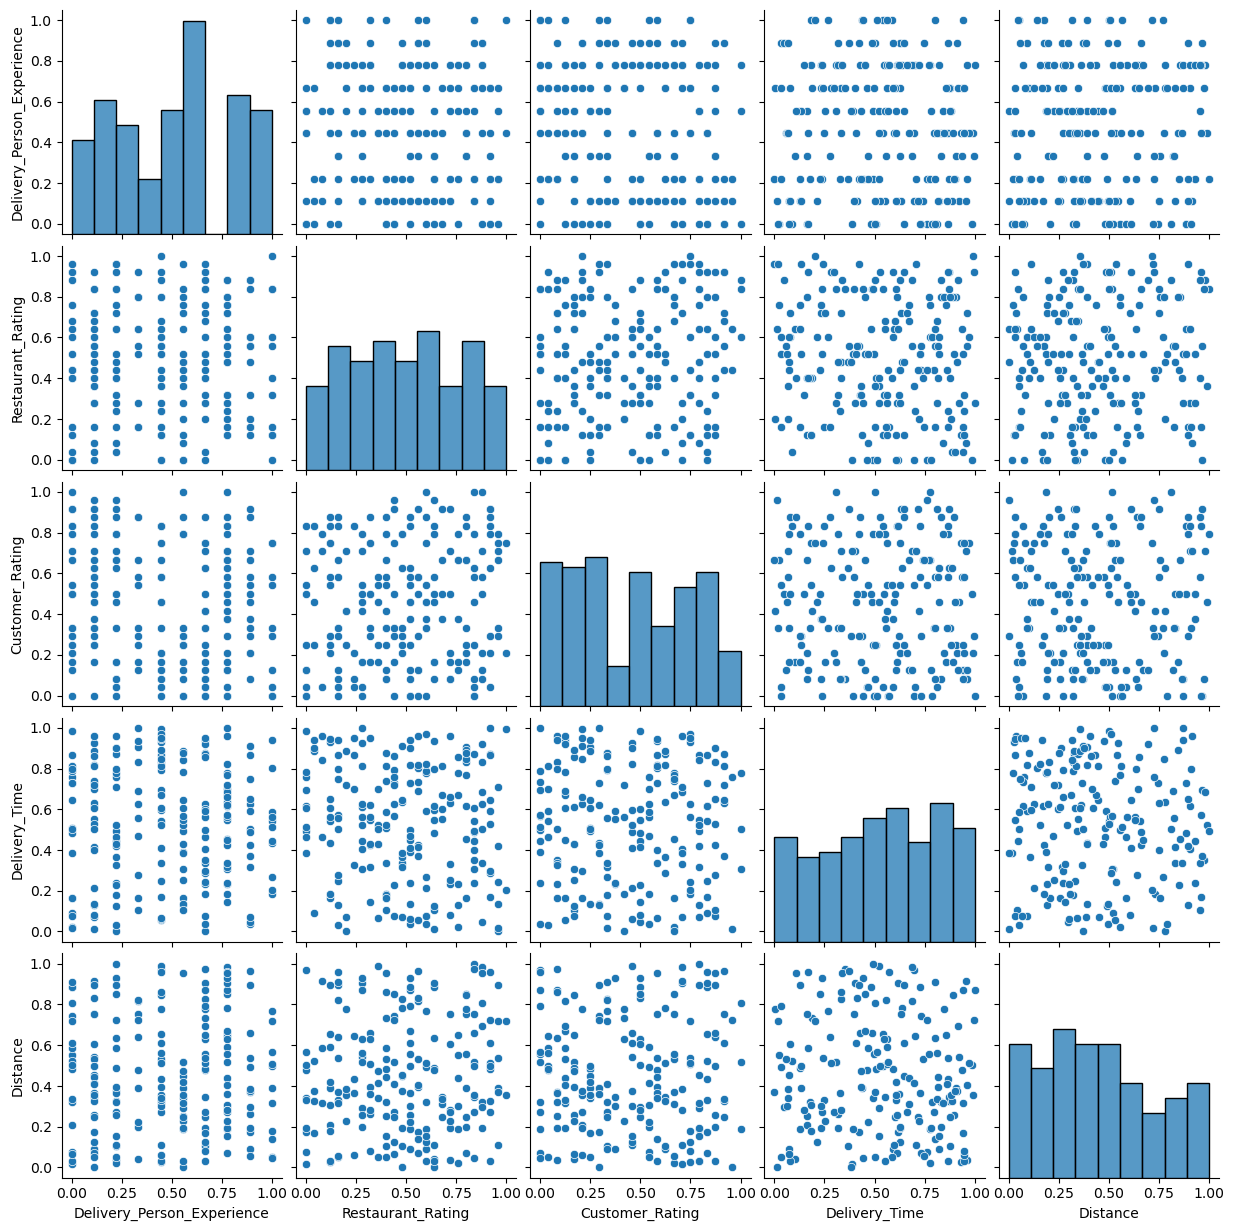

In [ ]:
sns.pairplot(df[num_cols])
plt.show()


<Axes: >

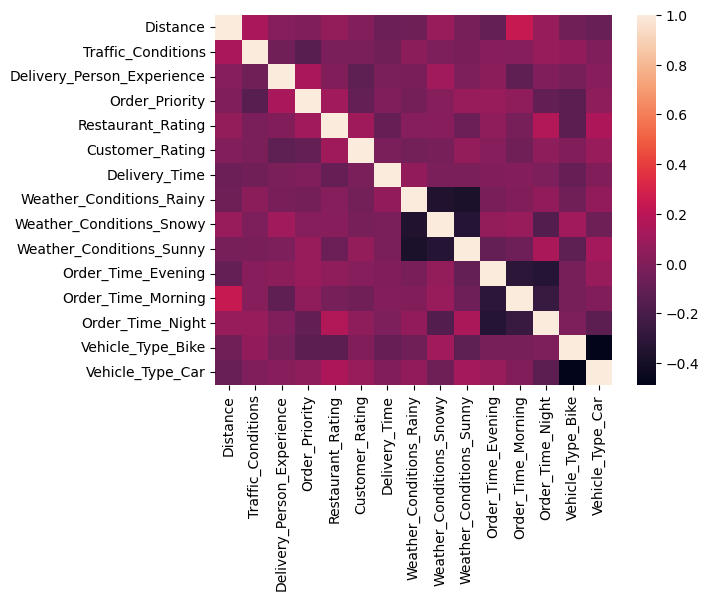

In [ ]:
sns.heatmap(df.corr())

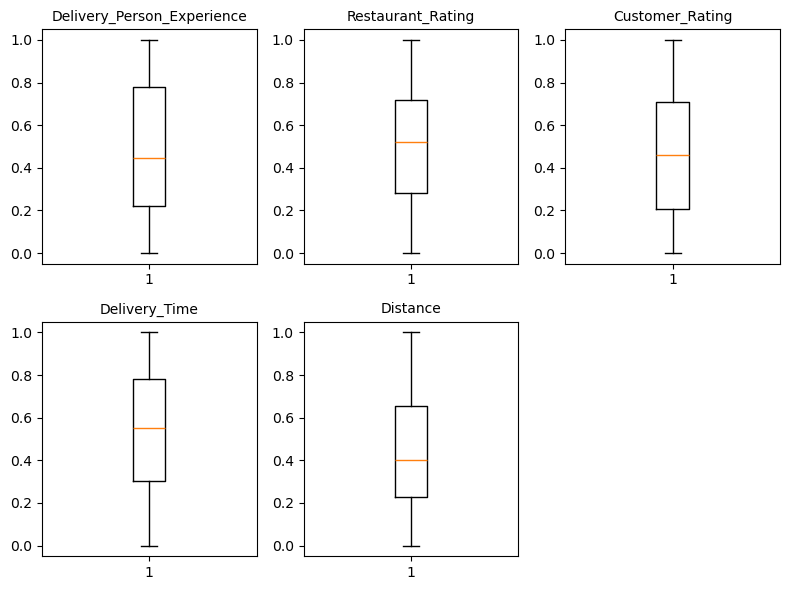

In [ ]:
import matplotlib.pyplot as plt
import math

n = len(num_cols)
cols = 3   # number of plots per row
rows = math.ceil(n / cols)

plt.figure(figsize=(8, 3 * rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols, i)
    plt.boxplot(df[col])
    plt.title(col, fontsize=10)

plt.tight_layout()
plt.show()


In [ ]:
pca = PCA(n_components = 5)
pca.fit(df)
data_pca = pca.transform(df)
data_pca = pd.DataFrame(data_pca,columns=['PC1','PC2','PC3','PC4','PC5'])
data_pca.head()

,PC1,PC2,PC3,PC4,PC5
0,0.012014,0.195470,-0.738081,0.350932,0.659103
1,-0.776330,-0.425837,-0.798255,-0.229503,-0.091540
2,0.578449,0.692020,1.063418,-0.443716,-0.010381
3,0.529420,-0.631520,0.657385,0.333366,-0.078818
4,-1.620304,0.207351,0.309707,-0.436912,0.887122


In [ ]:
from sklearn.preprocessing import KBinsDiscretizer

discretizer = KBinsDiscretizer(
    n_bins=3,
    encode="ordinal",
    strategy="quantile"
)

X_pca_disc = discretizer.fit_transform(df)

X_pca_disc = pd.DataFrame(
    X_pca_disc,
    columns=df.columns
)
X_pca_disc.head()

C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 3 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 7 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 8 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\preprocessing\_d

,Distance,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Restaurant_Rating,Customer_Rating,Delivery_Time,Weather_Conditions_Rainy,Weather_Conditions_Snowy,Weather_Conditions_Sunny,Order_Time_Evening,Order_Time_Morning,Order_Time_Night,Vehicle_Type_Bike,Vehicle_Type_Car
0,0.0,1.0,1.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,1.0,2.0,0.0,2.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,1.0,2.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,1.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
from sklearn.model_selection import train_test_split       # target
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
X_train, X_test, y_train, y_test = train_test_split(
  X_pca_disc, y, test_size=0.2, random_state=42
)
#from sklearn.linear_model import LinearRegression

# Create model
model = LinearRegression()

# Train (fit) the model
model.fit(X_train, y_train)
#from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predictions on test data
y_pred = model.predict(X_test)

In [ ]:
y,y_pred

(0       26.22
 1       62.61
 2       48.43
 3      111.63
 4       32.38
         ...  
 195     50.39
 196     90.54
 197     73.20
 198     53.94
 199     78.58
 Name: Delivery_Time, Length: 200, dtype: float64,
 array([102.58055581,  39.17066855, 105.23612135, 108.23747038,
         34.22226442,  69.30881957,  67.37132976, 104.11916194,
        107.26060794,  35.09917424,  71.11150462,  34.22226442,
         70.12148919,  69.79016974,  31.54293321, 107.66583768,
         38.45690417, 102.53936408,  36.51941436,  35.24717028,
         33.31727758,  33.94960106,  37.95911525,  35.51983363,
         72.55120551,  71.76125418, 104.21147916,  73.07374742,
         38.24062024, 104.40497829,  74.01263736,  35.61442752,
         67.74289835,  73.08690041, 102.06232526, 104.82336102,
         73.35525241, 104.44091609, 105.24927435,  65.62204686]))

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predictions on test data
#y_pred = model.predict(X_test)

# Evaluation metrics
mse  = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("-------------------------")
print("MSE  :", mse)
print("RMSE :", rmse)
print("MAE  :", mae)
print("R² Score:", r2)

Model Evaluation Results
-------------------------
MSE  : 124.31678124903178
RMSE : 11.149743550819085
MAE  : 9.40041205786434
R² Score: 0.8655876713060786


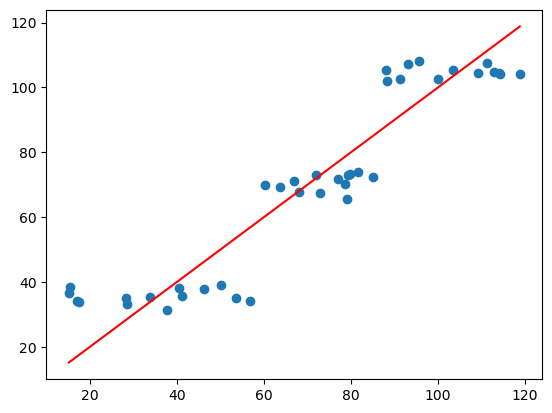

In [ ]:
plt.scatter(y_test,y_pred)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],color='red')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

# Assuming 'df' is your delivery dataset
# Create the binary target: 1 for Delayed, 0 for Fast (based on a threshold, e.g., 30 mins)
threshold = df['Delivery_Time'].median()
df['status'] = (df['Delivery_Time'] > threshold).astype(int)

# Features (X) and Target (y)
X_lo = X_pca_disc    #df[['Traffic', 'Weather', 'Delivery_Person_Exp']]
y_lo = df['status']

X_train_lo, X_test_lo, y_train_lo, y_test_lo = train_test_split(X_lo, y_lo, test_size=0.2, random_state=42)

model_lo = LogisticRegression(max_iter=1000, class_weight='balanced')
model_lo.fit(X_train_lo, y_train_lo)
y_pred_lo = model_lo.predict(X_test_lo)

In [ ]:
# Calculate metrics with appropriate parameters for categorical labels
accuracy = accuracy_score(y_test_lo, y_pred_lo)
precision = precision_score(y_test_lo, y_pred_lo, average='weighted', pos_label='Delayed')  # Specify pos_label and average
recall = recall_score(y_test_lo, y_pred_lo, average='weighted', pos_label='Delayed')  # Specify pos_label and average
f1 = f1_score(y_test_lo, y_pred_lo, average='weighted', pos_label='Delayed')  # Specify pos_label and average
cm = confusion_matrix(y_test_lo, y_pred_lo)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Confusion Matrix:\n", cm)

Accuracy: 0.9
Precision: 0.9045112781954888
Recall: 0.9
F1-score: 0.9
Confusion Matrix:
 [[18  1]
 [ 3 18]]


C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1618: UserWarning: Note that pos_label (set to 'Delayed') is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1618: UserWarning: Note that pos_label (set to 'Delayed') is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1618: UserWarning: Note that pos_label (set to 'Delayed') is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


In [ ]:
#label_mapping = {0: 'Fast', 1:  'Delayed'}
# Mapping
label_mapping = {0: 'Fast', 1: 'Delayed'}

# Convert test labels → text
y_test_labels = [label_mapping[int(t)] for t in y_test_lo]

# Convert predicted labels → text
y_pred_labels = [label_mapping[int(p)] for p in y_pred_lo]

# Create results dataframe
df_results = pd.DataFrame({
    'Actual': y_test_labels,
    'Predicted': y_pred_labels
})

print(df_results.head())



    Actual Predicted
0  Delayed   Delayed
1     Fast      Fast
2  Delayed   Delayed
3  Delayed   Delayed
4     Fast      Fast


In [ ]:
y_pred_labels

['Delayed',
 'Fast',
 'Delayed',
 'Delayed',
 'Fast',
 'Fast',
 'Delayed',
 'Delayed',
 'Delayed',
 'Fast',
 'Fast',
 'Fast',
 'Fast',
 'Fast',
 'Fast',
 'Delayed',
 'Fast',
 'Delayed',
 'Fast',
 'Fast',
 'Fast',
 'Fast',
 'Fast',
 'Fast',
 'Delayed',
 'Delayed',
 'Delayed',
 'Delayed',
 'Fast',
 'Delayed',
 'Fast',
 'Fast',
 'Fast',
 'Delayed',
 'Delayed',
 'Delayed',
 'Fast',
 'Delayed',
 'Delayed',
 'Delayed']

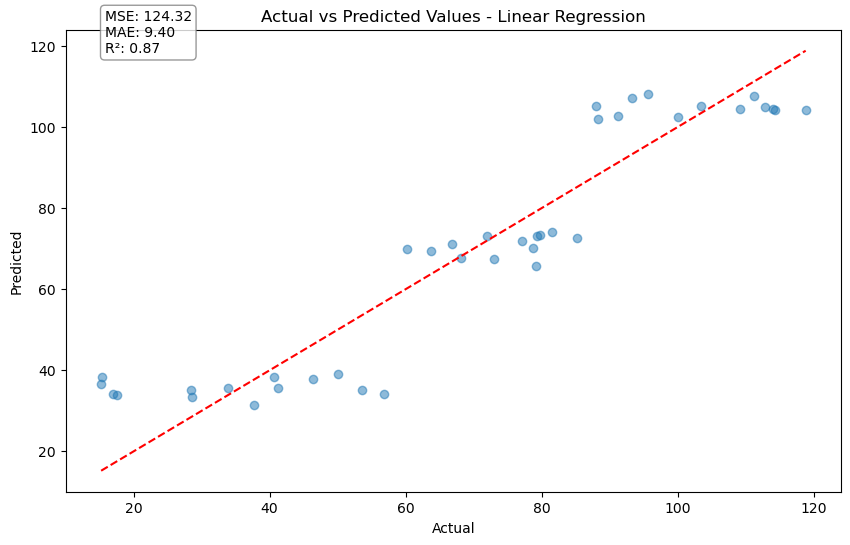

In [ ]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Create a visualization of actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Actual vs Predicted Values - Linear Regression')
plt.xlabel('Actual')
plt.ylabel('Predicted')

# Add metrics information to the plot
plt.annotate(f'MSE: {mse:.2f}\nMAE: {mae:.2f}\nR²: {r2:.2f}',
             xy=(0.05, 0.95), xycoords='axes fraction',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
plt.show()

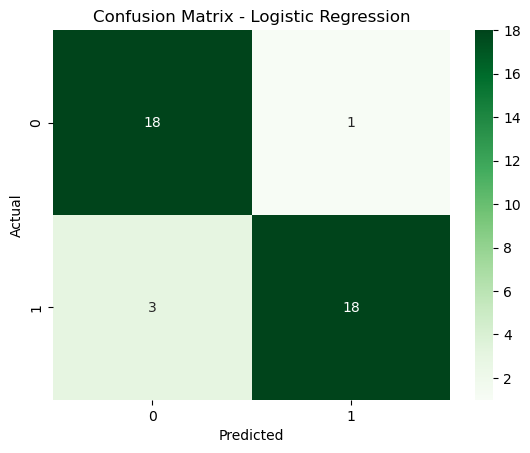

In [ ]:
cm_log = confusion_matrix(y_test_lo, y_pred_lo)

sns.heatmap(cm_log, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


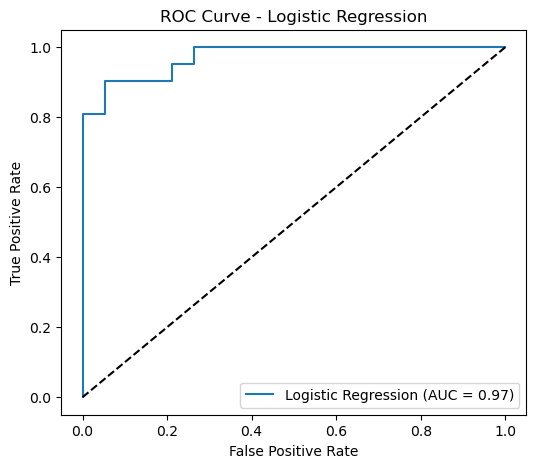

In [ ]:
# ROC Curve for Logistic Regression ONLY

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Predicted probabilities for the positive class (Fast = 1)
y_prob = model_lo.predict_proba(X_test_lo)[:, 1]

# ROC curve values
fpr, tpr, _ = roc_curve(y_test_lo, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.show()

